# Threat Intelligence Graph Analytics

Connect synthetic indicators, infrastructure, techniques, campaigns, and enterprise assets into an evidence graph.

**Safety and scope:** This project uses synthetic, non-sensitive telemetry for defensive analytics. It does not perform exploitation or execute malicious content.

## Goal

Implement PageRank and bounded evidence-path search to prioritize connected entities and exposed assets.


## Setup

The notebook is deterministic, runs offline, and implements the core analytical method directly with NumPy and Pandas so the modeling logic remains inspectable.


In [1]:
from collections import defaultdict, deque

import numpy as np
import pandas as pd

pd.set_option("display.width", 130)

def build_adjacency(edges):
    adjacency = defaultdict(set)
    for source, target, relation in edges:
        adjacency[source].add(target)
        adjacency[target].add(source)
    return adjacency

def pagerank(nodes, adjacency, damping=0.85, iterations=80):
    scores = {node: 1.0 / len(nodes) for node in nodes}
    for _ in range(iterations):
        updated = {node: (1 - damping) / len(nodes) for node in nodes}
        for node in nodes:
            neighbors = adjacency[node]
            if neighbors:
                share = damping * scores[node] / len(neighbors)
                for neighbor in neighbors:
                    updated[neighbor] += share
        scores = updated
    return scores

def shortest_path(adjacency, start, goal, max_depth=5):
    queue = deque([(start, [start])])
    visited = {start}
    while queue:
        node, path = queue.popleft()
        if node == goal:
            return path
        if len(path) - 1 >= max_depth:
            continue
        for neighbor in sorted(adjacency[node]):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    return None


## Steps

### 1. Build a synthetic CTI graph


In [2]:
node_types = {
    "indicator:alpha.test": "indicator",
    "indicator:203.0.113.50": "indicator",
    "indicator:hash-demo-01": "indicator",
    "infra:edge-relay": "infrastructure",
    "infra:mail-gateway": "infrastructure",
    "malware:sample-a": "malware",
    "campaign:aurora-demo": "campaign",
    "actor:group-demo": "threat_actor",
    "technique:T1566": "technique",
    "technique:T1059": "technique",
    "asset:finance-laptop": "asset",
    "asset:identity-server": "asset",
    "asset:web-server": "asset",
}
edges = [
    ("indicator:alpha.test", "infra:edge-relay", "resolves_to"),
    ("indicator:203.0.113.50", "infra:edge-relay", "hosts"),
    ("indicator:hash-demo-01", "malware:sample-a", "hash_of"),
    ("infra:edge-relay", "campaign:aurora-demo", "used_by"),
    ("infra:mail-gateway", "campaign:aurora-demo", "used_by"),
    ("malware:sample-a", "campaign:aurora-demo", "associated_with"),
    ("campaign:aurora-demo", "actor:group-demo", "attributed_to"),
    ("campaign:aurora-demo", "technique:T1566", "uses"),
    ("malware:sample-a", "technique:T1059", "uses"),
    ("asset:finance-laptop", "indicator:alpha.test", "observed"),
    ("asset:web-server", "indicator:203.0.113.50", "observed"),
    ("asset:identity-server", "infra:mail-gateway", "communicated_with"),
]
adjacency = build_adjacency(edges)
print("Nodes:", len(node_types), "Edges:", len(edges))
print(pd.DataFrame(edges, columns=["source", "target", "relation"]).to_string(index=False))


Nodes: 13 Edges: 12
                source                 target          relation
  indicator:alpha.test       infra:edge-relay       resolves_to
indicator:203.0.113.50       infra:edge-relay             hosts
indicator:hash-demo-01       malware:sample-a           hash_of
      infra:edge-relay   campaign:aurora-demo           used_by
    infra:mail-gateway   campaign:aurora-demo           used_by
      malware:sample-a   campaign:aurora-demo   associated_with
  campaign:aurora-demo       actor:group-demo     attributed_to
  campaign:aurora-demo        technique:T1566              uses
      malware:sample-a        technique:T1059              uses
  asset:finance-laptop   indicator:alpha.test          observed
      asset:web-server indicator:203.0.113.50          observed
 asset:identity-server     infra:mail-gateway communicated_with


### 2. Rank entities and find evidence paths


In [3]:
centrality = pagerank(list(node_types), adjacency)
centrality_table = pd.DataFrame({
    "entity": list(centrality),
    "type": [node_types[node] for node in centrality],
    "pagerank": list(centrality.values()),
    "degree": [len(adjacency[node]) for node in centrality],
}).sort_values("pagerank", ascending=False)

indicators = [node for node, node_type in node_types.items() if node_type == "indicator"]
assets = [node for node, node_type in node_types.items() if node_type == "asset"]
evidence_paths = []
for indicator in indicators:
    for asset in assets:
        path = shortest_path(adjacency, indicator, asset, max_depth=4)
        if path:
            evidence_paths.append({
                "indicator": indicator,
                "asset": asset,
                "hops": len(path) - 1,
                "path": " -> ".join(path),
            })
evidence_table = pd.DataFrame(evidence_paths).sort_values(["hops", "asset", "indicator"])

print("Highest-centrality entities:")
print(centrality_table.head(8).round(4).to_string(index=False))
print("\nBounded indicator-to-asset evidence paths:")
print(evidence_table.head(12).to_string(index=False))


Highest-centrality entities:
                entity           type  pagerank  degree
  campaign:aurora-demo       campaign    0.1884       5
      malware:sample-a        malware    0.1219       3
      infra:edge-relay infrastructure    0.1155       3
  indicator:alpha.test      indicator    0.0847       2
indicator:203.0.113.50      indicator    0.0847       2
    infra:mail-gateway infrastructure    0.0836       2
  asset:finance-laptop          asset    0.0475       1
      asset:web-server          asset    0.0475       1

Bounded indicator-to-asset evidence paths:
             indicator                 asset  hops                                                                                                              path
  indicator:alpha.test  asset:finance-laptop     1                                                                      indicator:alpha.test -> asset:finance-laptop
indicator:203.0.113.50      asset:web-server     1                                           

## Visual Insights & ML Extension

The original transparent method remains intact. This extension adds an explicit visual story, a stronger scikit-learn benchmark, and analyst-focused interpretation. All evaluation uses held-out or label-free synthetic examples as appropriate.

**Reading the results:** model scores describe this generated dataset only. They are not production performance claims and should not replace temporal validation, calibration, drift checks, or human review.


                  nodes  mean_pagerank  entity_types
spectral_cluster                                    
0                     3         0.0713             3
1                     3         0.0826             3
2                     5         0.0812             5
3                     2         0.0661             2

Analyst takeaways:
- Four spectral clusters summarize 13 entities without using node-type labels.
- campaign:aurora-demo remains the strongest central pivot by PageRank.
- Community membership is an investigation aid, not evidence of common ownership or attribution.


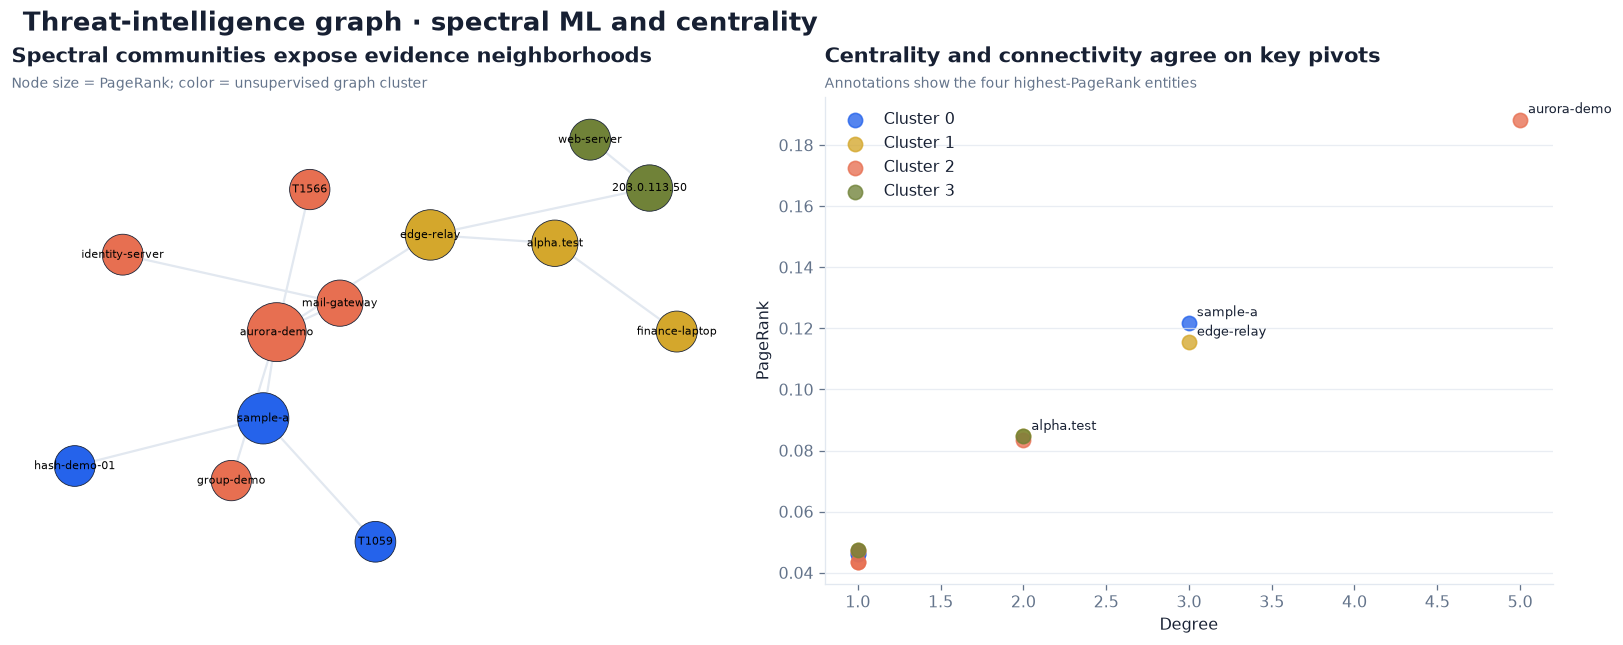

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = globals().get("SEED", 42)

PALETTE = {
    "blue": "#2563EB",
    "gold": "#D4A72C",
    "orange": "#E76F51",
    "olive": "#708238",
    "pink": "#C65D86",
    "ink": "#172033",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "paper": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
})

def polish_axis(ax, title, subtitle, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)

def binary_model_comparison(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.28,
        random_state=SEED,
        stratify=labels,
    )
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        ),
    }
    rows = []
    probabilities = {}
    fitted = {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        probability = model.predict_proba(x_test)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, probability),
            "average_precision": average_precision_score(y_test, probability),
            "f1_at_0_5": f1_score(y_test, prediction, zero_division=0),
        })
        probabilities[name] = probability
        fitted[name] = model
    return pd.DataFrame(rows).set_index("model"), fitted, probabilities, y_test

import networkx as nx

graph = nx.Graph()
graph.add_nodes_from(node_types)
graph.add_edges_from((source, target) for source, target, _ in edges)
graph_nodes = list(graph.nodes())
adjacency_matrix = nx.to_numpy_array(graph, nodelist=graph_nodes)
degrees = adjacency_matrix.sum(axis=1)
inv_sqrt_degree = np.diag(1 / np.sqrt(np.maximum(degrees, 1)))
normalized_laplacian = np.eye(len(graph_nodes)) - inv_sqrt_degree @ adjacency_matrix @ inv_sqrt_degree
eigenvalues, eigenvectors = np.linalg.eigh(normalized_laplacian)
graph_embedding = eigenvectors[:, 1:4]
graph_clusters = KMeans(n_clusters=4, n_init=30, random_state=SEED).fit_predict(graph_embedding)
graph_cluster_table = pd.DataFrame({
    "entity": graph_nodes,
    "type": [node_types[node] for node in graph_nodes],
    "spectral_cluster": graph_clusters,
    "pagerank": [centrality[node] for node in graph_nodes],
    "degree": degrees.astype(int),
}).sort_values("pagerank", ascending=False)

position = nx.spring_layout(graph, seed=SEED, k=0.85)
graph_colors = [PALETTE["blue"], PALETTE["gold"], PALETTE["orange"], PALETTE["olive"]]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
nx.draw_networkx_edges(graph, position, ax=axes[0], edge_color=PALETTE["grid"], width=1.4)
nx.draw_networkx_nodes(
    graph,
    position,
    ax=axes[0],
    node_color=[graph_colors[value] for value in graph_clusters],
    node_size=[420 + 5000 * centrality[node] for node in graph_nodes],
    edgecolors=PALETTE["ink"],
    linewidths=0.5,
)
short_labels = {node: node.split(":", 1)[-1] for node in graph_nodes}
nx.draw_networkx_labels(graph, position, labels=short_labels, ax=axes[0], font_size=7)
axes[0].set_title("Spectral communities expose evidence neighborhoods", loc="left", pad=22)
axes[0].text(0, 1.02, "Node size = PageRank; color = unsupervised graph cluster", transform=axes[0].transAxes, color=PALETTE["muted"], fontsize=9)
axes[0].axis("off")

for cluster_id, color in enumerate(graph_colors):
    subset = graph_cluster_table[graph_cluster_table["spectral_cluster"] == cluster_id]
    axes[1].scatter(subset["degree"], subset["pagerank"], s=80, alpha=0.78, color=color, label=f"Cluster {cluster_id}")
for _, row in graph_cluster_table.head(4).iterrows():
    axes[1].annotate(row["entity"].split(":", 1)[-1], (row["degree"], row["pagerank"]), xytext=(5, 4), textcoords="offset points", fontsize=8)
axes[1].legend(frameon=False)
polish_axis(axes[1], "Centrality and connectivity agree on key pivots", "Annotations show the four highest-PageRank entities", "Degree", "PageRank")
fig.suptitle("Threat-intelligence graph · spectral ML and centrality", fontsize=16, fontweight="bold", x=0.01, ha="left")

cluster_summary = graph_cluster_table.groupby("spectral_cluster").agg(nodes=("entity", "count"), mean_pagerank=("pagerank", "mean"), entity_types=("type", "nunique"))
print(cluster_summary.round(4).to_string())
print("\nAnalyst takeaways:")
print(f"- Four spectral clusters summarize {len(graph_nodes)} entities without using node-type labels.")
print(f"- {graph_cluster_table.iloc[0]['entity']} remains the strongest central pivot by PageRank.")
print("- Community membership is an investigation aid, not evidence of common ownership or attribution.")


## Checks


In [5]:
assert abs(sum(centrality.values()) - 1.0) < 1e-6
assert len(evidence_table) >= 3
assert evidence_table["hops"].max() <= 4
assert "campaign:aurora-demo" in set(centrality_table.head(5)["entity"])
print("Checks passed: normalized PageRank, bounded paths, and a central campaign entity.")


Checks passed: normalized PageRank, bounded paths, and a central campaign entity.


## Next Steps

        - Add timestamps, confidence, provenance, and marking constraints to every relationship.
- Score paths using source reliability and enterprise-observation recency.
- Persist the graph in a graph database and expose analyst-friendly evidence views.
